# 02 — Forecasting GRU Baseline
### GRU binary forecaster — Baseline 2
> Run 00_Data_Preparation.ipynb first.
>
> Predicts: will a breakdown happen within the next 5 pedal presses?


In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')


✅ Device: cpu


In [2]:
with open('prepared_forecasting.pkl','rb') as f: d = pickle.load(f)

X_train = torch.FloatTensor(d['X_fc_train_seq']).to(DEVICE)
X_test  = torch.FloatTensor(d['X_fc_test_seq']).to(DEVICE)
y_train = torch.LongTensor(d['y_fc_train_bin_seq']).to(DEVICE)
y_test  = torch.LongTensor(d['y_fc_test_bin_seq']).to(DEVICE)

NUM_FEATURES = d['num_features']
TIME_STEPS   = d['TIME_STEPS']

# CLASS WEIGHTS
class_counts  = np.bincount(d['y_fc_train_bin_seq'])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f'✅ Data loaded. Features: {NUM_FEATURES}, TIME_STEPS: {TIME_STEPS}')
print(f'   Class counts  : {class_counts}')
print(f'   Class weights : {class_weights.round(3)}')

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)


✅ Data loaded. Features: 67, TIME_STEPS: 5
   Class counts  : [3700  252]
   Class weights : [0.128 1.872]


#### GRU Forecaster Architecture


In [3]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.gru  = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.bn   = nn.BatchNorm1d(hidden_size)
        self.fc1  = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(32, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.bn(out[:, -1, :])
        out = self.drop(self.relu(self.fc1(out)))
        return self.fc2(out)

model = GRUForecaster(NUM_FEATURES, hidden_size=64, num_layers=2,
                      num_classes=2).to(DEVICE)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


GRUForecaster(
  (gru): GRU(67, 64, num_layers=2, batch_first=True, dropout=0.3)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)
Parameters: 52,770


#### Train


Epoch   1 | Train: 0.7127 | Val: 0.7272
Epoch   2 | Train: 0.7029 | Val: 0.7590
Epoch   3 | Train: 0.6838 | Val: 0.7669
Epoch   4 | Train: 0.6828 | Val: 0.7433
Epoch   5 | Train: 0.6877 | Val: 0.7620
Epoch   6 | Train: 0.6646 | Val: 0.7668
Epoch   7 | Train: 0.6510 | Val: 0.8003
Epoch   8 | Train: 0.6410 | Val: 0.8591
Epoch   9 | Train: 0.6269 | Val: 0.9394
Epoch  10 | Train: 0.6300 | Val: 0.8834
Epoch  11 | Train: 0.5918 | Val: 0.9108
Epoch  12 | Train: 0.5933 | Val: 0.9345
Epoch  13 | Train: 0.5822 | Val: 0.9543
Epoch  14 | Train: 0.5828 | Val: 0.9284
Epoch  15 | Train: 0.5746 | Val: 0.9369
Epoch  16 | Train: 0.5667 | Val: 0.9648
Epoch  17 | Train: 0.5768 | Val: 0.9991
Epoch  18 | Train: 0.5691 | Val: 0.9851
Epoch  19 | Train: 0.5712 | Val: 0.9693
Epoch  20 | Train: 0.5817 | Val: 0.9739
Early stopping at epoch 21


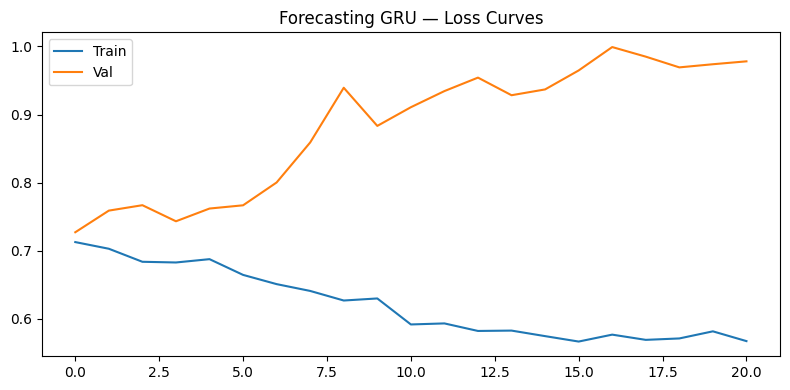

In [4]:
EPOCHS    = 150
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 20
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test), y_test).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_forecast_gru.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Forecasting GRU — Loss Curves')
plt.legend()
plt.tight_layout()
plt.savefig('forecast_gru_loss.png', dpi=150)
plt.show()


#### Evaluate


FORECASTING GRU BASELINE RESULTS
Accuracy : 92.08%
F1 Score : 0.9019
RMSE     : 0.2814
MAE      : 0.0792

                  precision    recall  f1-score   support

            Safe       0.94      0.98      0.96       922
Breakdown Coming       0.14      0.05      0.07        63

        accuracy                           0.92       985
       macro avg       0.54      0.51      0.52       985
    weighted avg       0.89      0.92      0.90       985



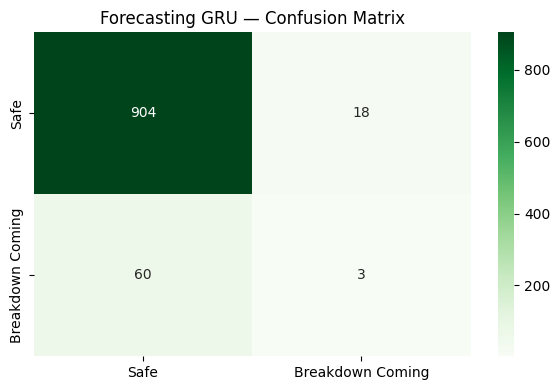

✅ Results saved.


In [5]:
model.load_state_dict(torch.load('best_forecast_gru.pt'))
model.eval()
with torch.no_grad():
    y_pred = np.argmax(torch.softmax(model(X_test),dim=1).cpu().numpy(), axis=1)
    y_true = y_test.cpu().numpy()

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print('='*50)
print('FORECASTING GRU BASELINE RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['Safe','Breakdown Coming']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Safe','Breakdown Coming'],
            yticklabels=['Safe','Breakdown Coming'])
plt.title('Forecasting GRU — Confusion Matrix')
plt.tight_layout()
plt.savefig('forecast_gru_confusion.png', dpi=150)
plt.show()

gru_results = {'model':'GRU Forecaster','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae}
with open('forecast_gru_results.pkl','wb') as f: pickle.dump(gru_results, f)
print('✅ Results saved.')
